In [1]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\Thrace\GR_Thrace_Timeline_GRID_2018-2020_filled.csv', encoding='utf-8', low_memory=False)

In [3]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

<Axes: >

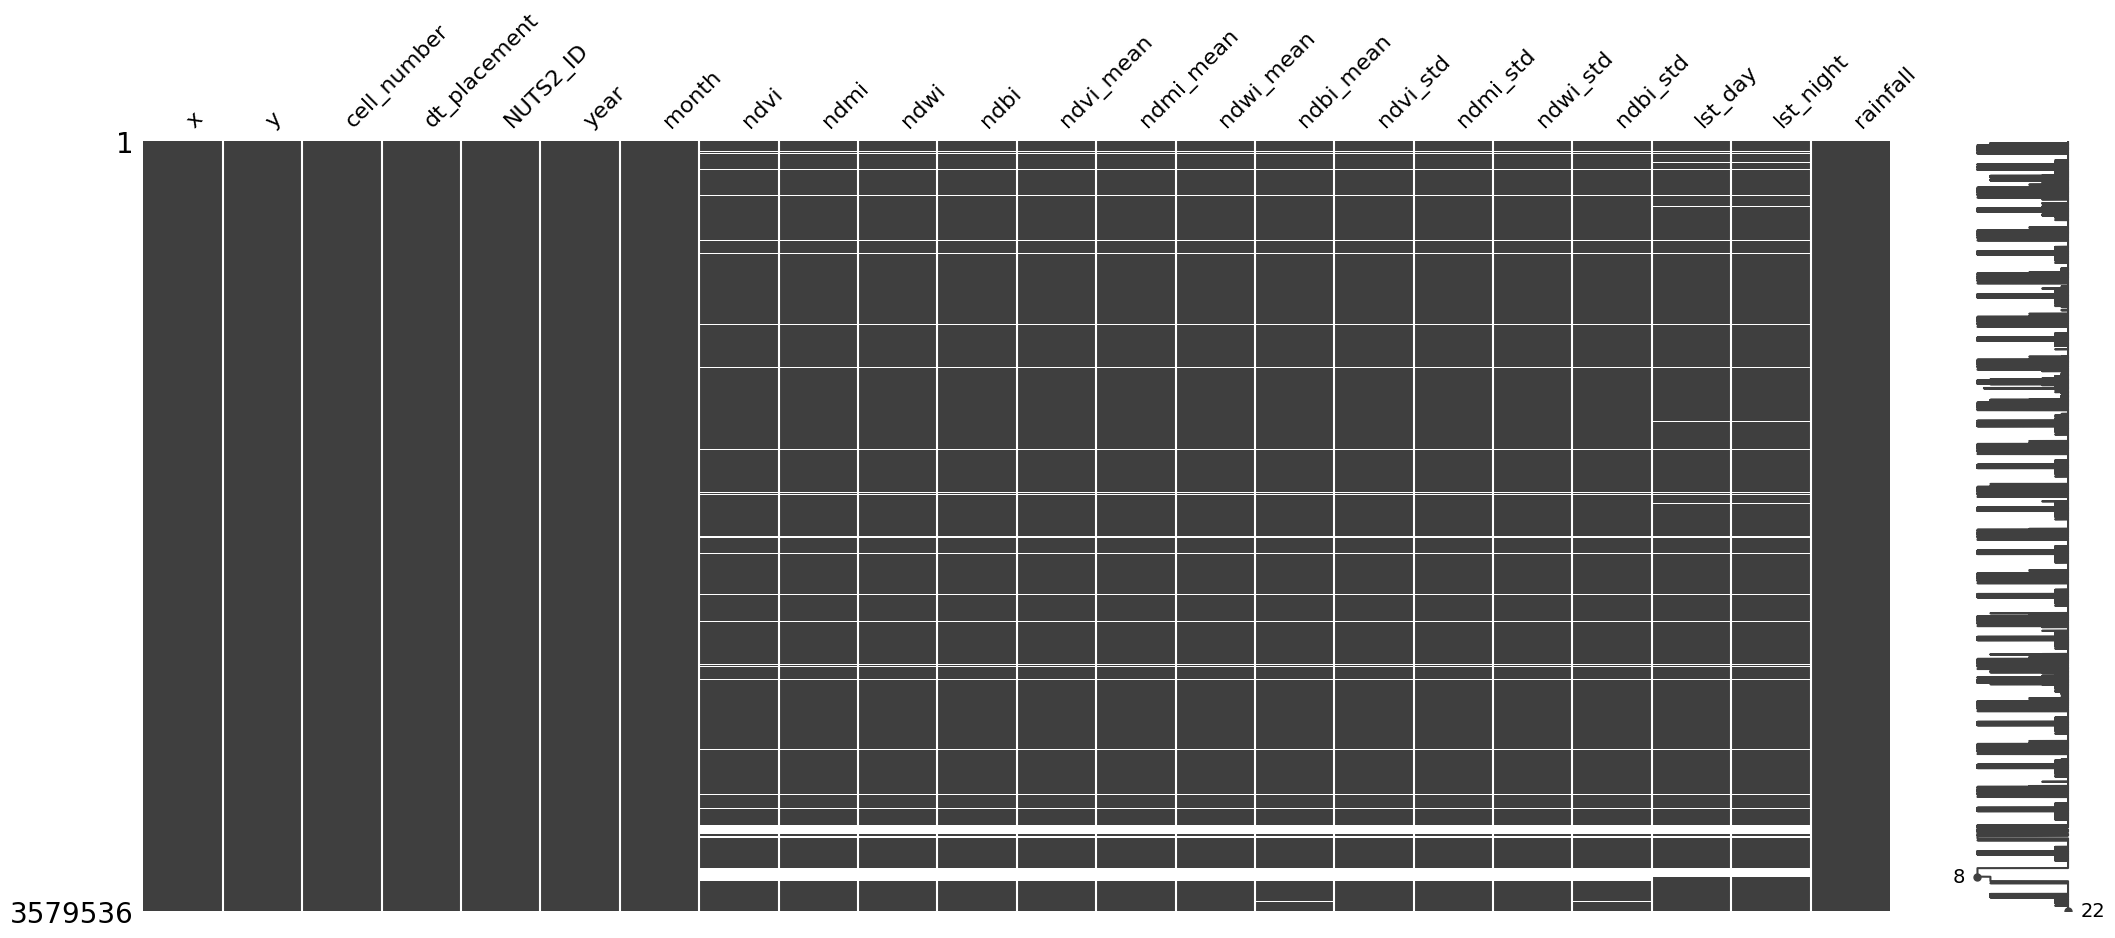

In [4]:
missingno.matrix(data)

In [5]:
data.dtypes

x               float64
y               float64
cell_number       int64
dt_placement     object
NUTS2_ID         object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day          object
lst_night       float64
rainfall        float64
dtype: object

In [6]:
# data.lst_day.unique()

array(['14093.0', '13931.0', '13783.0', ..., '2020-12-13', '2020-12-14',
       '2020-12-15'], dtype=object)

In [7]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [8]:
# data['lst_day'] = data['lst_day'].astype(float)

In [9]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [10]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [11]:
data

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,23.65882,41.33542,0,2018-01-01,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,14093.0,13642.000000,0.000000,1
1,23.65882,41.33542,0,2018-01-02,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13931.0,13642.000000,2.953801,2
2,23.65882,41.33542,0,2018-01-03,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13488.000000,0.000000,3
3,23.65882,41.33542,0,2018-01-04,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13515.000000,3.852192,4
4,23.65882,41.33542,0,2018-01-05,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13515.000000,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579531,26.60756,41.40729,3265,2020-12-27,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,40.110161,27
3579532,26.60756,41.40729,3265,2020-12-28,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,10.648291,28
3579533,26.60756,41.40729,3265,2020-12-29,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,1.150095,29
3579534,26.60756,41.40729,3265,2020-12-30,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,0.027165,30


In [12]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [13]:
df_mean_jan = data_jan.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [14]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [15]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [16]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['cell_number', 'year']).merge(df_mean_mar, on=['cell_number', 'year']).merge(df_mean_apr, on=['cell_number', 'year'])

In [17]:
df_mean.loc[(df_mean['cell_number'] == 0) & (df_mean['year'] == 2014)]

,cell_number,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean


In [18]:
data_mean = pd.merge(data, df_mean, on=['cell_number', 'year'])

In [19]:
data_mean

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,23.65882,41.33542,0,2018-01-01,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,14093.0,13642.000000,0.000000,1,13877.354839,13637.354839,13989.714286,13643.392857,14153.612903,13769.354839,14733.700000,14052.000000
1,23.65882,41.33542,0,2018-01-02,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13931.0,13642.000000,2.953801,2,13877.354839,13637.354839,13989.714286,13643.392857,14153.612903,13769.354839,14733.700000,14052.000000
2,23.65882,41.33542,0,2018-01-03,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13488.000000,0.000000,3,13877.354839,13637.354839,13989.714286,13643.392857,14153.612903,13769.354839,14733.700000,14052.000000
3,23.65882,41.33542,0,2018-01-04,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13515.000000,3.852192,4,13877.354839,13637.354839,13989.714286,13643.392857,14153.612903,13769.354839,14733.700000,14052.000000
4,23.65882,41.33542,0,2018-01-05,EL51,2018,1,0.075421,0.163148,0.062645,-0.163148,0.146046,0.072780,-0.063395,-0.072780,0.097993,0.055410,0.113606,0.055410,13783.0,13515.000000,0.000000,5,13877.354839,13637.354839,13989.714286,13643.392857,14153.612903,13769.354839,14733.700000,14052.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579531,26.60756,41.40729,3265,2020-12-27,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,40.110161,27,14099.225806,13492.870968,14269.241379,13800.586207,14750.290323,13907.612903,14912.933333,13992.366667
3579532,26.60756,41.40729,3265,2020-12-28,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,10.648291,28,14099.225806,13492.870968,14269.241379,13800.586207,14750.290323,13907.612903,14912.933333,13992.366667
3579533,26.60756,41.40729,3265,2020-12-29,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,1.150095,29,14099.225806,13492.870968,14269.241379,13800.586207,14750.290323,13907.612903,14912.933333,13992.366667
3579534,26.60756,41.40729,3265,2020-12-30,EL51,2020,12,0.450774,0.156466,-0.351211,-0.156466,0.200367,-0.010449,-0.132835,0.010449,0.117562,0.077335,0.106493,0.077335,NaN,41.405597,0.027165,30,14099.225806,13492.870968,14269.241379,13800.586207,14750.290323,13907.612903,14912.933333,13992.366667


<Axes: >

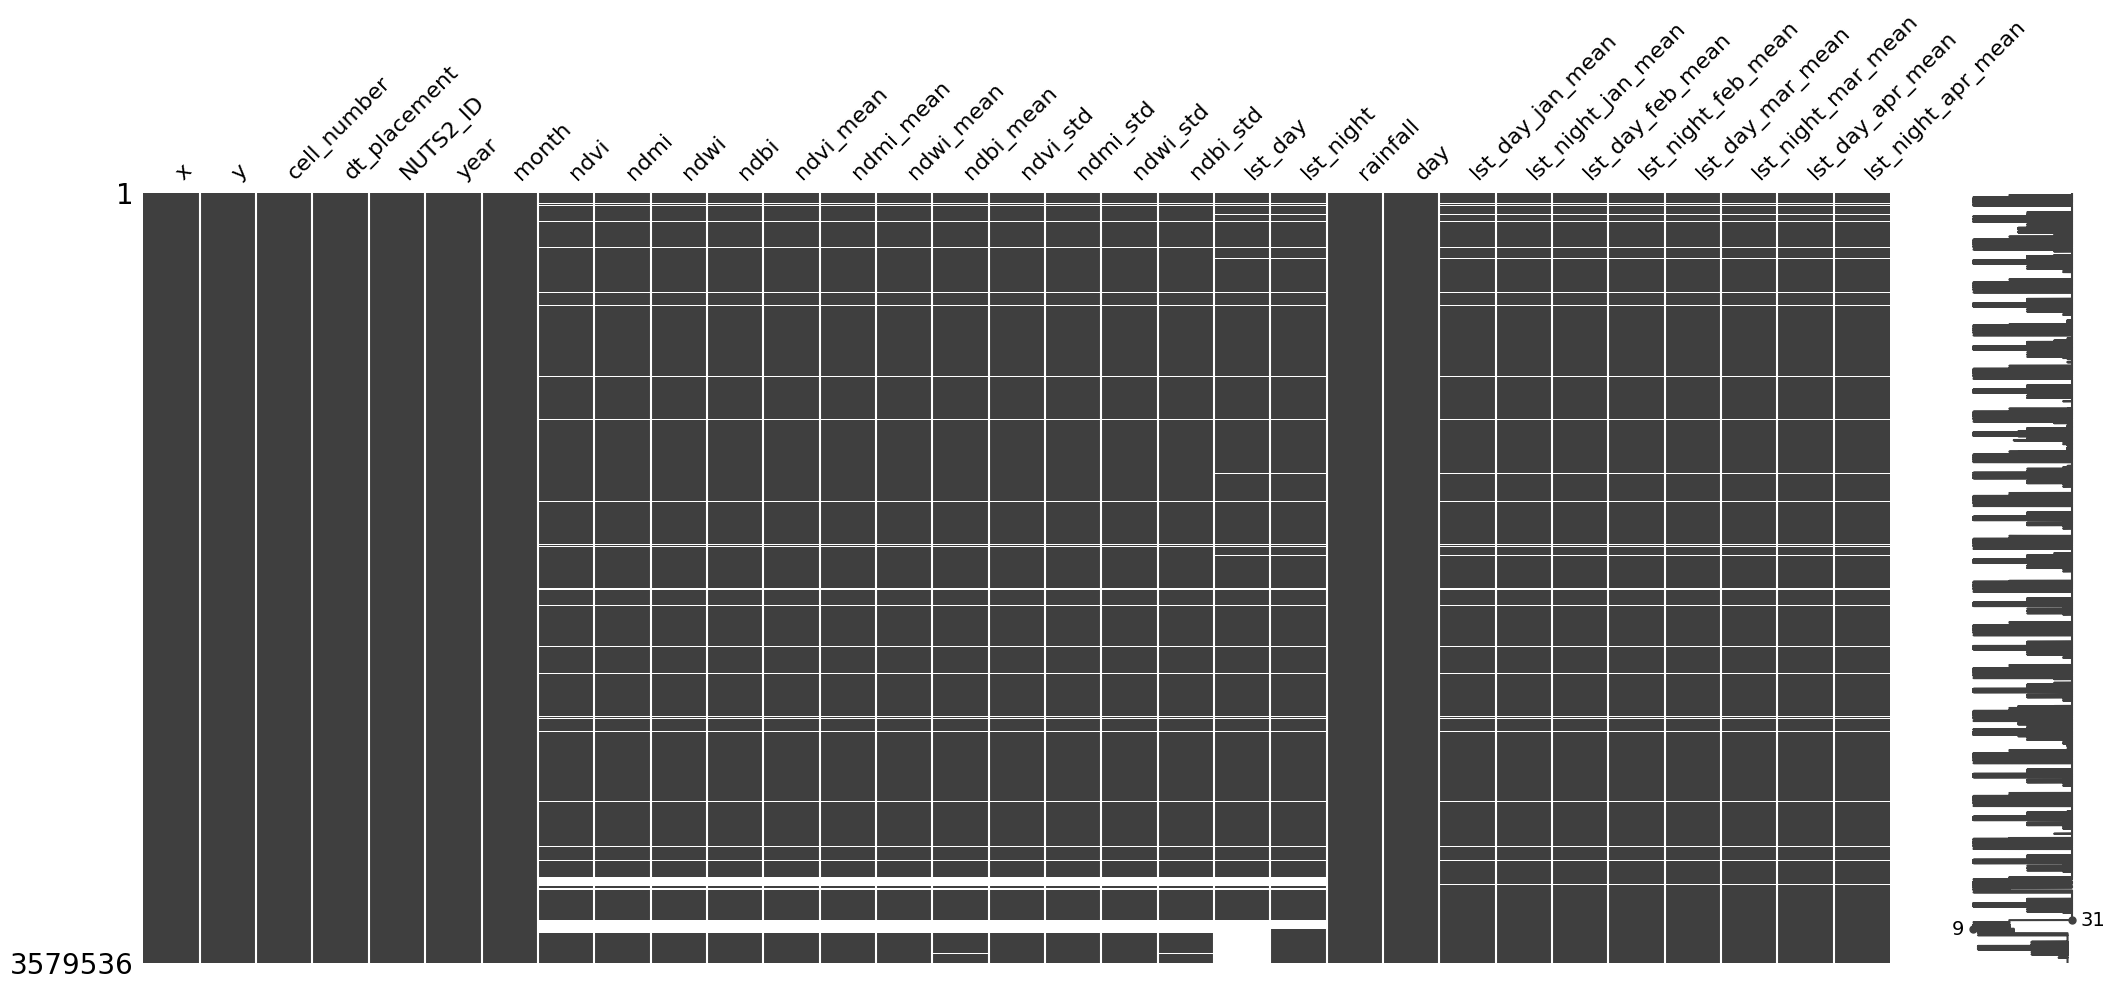

In [20]:
missingno.matrix(data_mean)

In [21]:
data_mean.to_csv(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\Thrace\GR_Thrace_Timeline_GRID_2018-2020_filled_mean.csv', encoding='utf-8')